# Real Stock Data Science Workflow (.ipynb)

โน้ตบุ๊กนี้ใช้ **ข้อมูลหุ้นจริง** จาก Yahoo Finance และทำตามขั้นตอน Data Science ครบกระบวนการ: 
- Data acquisition
- Data quality checks
- Cleaning + time index handling
- EDA
- Feature engineering
- Time-based split
- Baseline + ML + ARIMA
- Walk-forward backtesting
- Metrics + residual analysis
- Model/artifact export

> หมายเหตุ: ต้องมีอินเทอร์เน็ตเพื่อดึงข้อมูลจริง

## 1) ตั้งค่า Environment และติดตั้งแพ็กเกจ
ติดตั้ง/นำเข้าไลบรารีที่จำเป็น และตั้งค่า seed เพื่อให้รันซ้ำได้ (reproducible).

In [19]:
# Run once per kernel if packages are missing
import sys
!{sys.executable} -m pip install -q seaborn scikit-learn statsmodels xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Uncomment if running first time in a fresh environment
# %pip install -q numpy pandas matplotlib seaborn yfinance scikit-learn statsmodels xgboost pyswarm

import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

print("Environment ready")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Environment ready
pandas: 3.0.1
numpy: 2.4.2


## 2) ดึงข้อมูลหุ้นย้อนหลังจากแหล่งข้อมูลจริง (Yahoo Finance)
ใช้ `yfinance` ดึงข้อมูลจริง 5 ปีย้อนหลังของหุ้น 30 ตัว (S&P500 large caps)

In [21]:
TICKERS = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "BRK-B", "JPM", "V",
    "JNJ", "WMT", "PG", "UNH", "MA", "HD", "XOM", "CVX", "LLY", "MRK",
    "ABBV", "PEP", "KO", "COST", "BAC", "AVGO", "ADBE", "CRM", "PFE", "CSCO"
]

raw = yf.download(
    tickers=TICKERS,
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False,
    threads=True
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
    volume = raw["Volume"].copy() if "Volume" in raw.columns.get_level_values(0) else None
else:
    prices = raw.copy()
    volume = None

print("Raw prices shape:", prices.shape)
prices.head()

Raw prices shape: (1255, 30)


Ticker,AAPL,ABBV,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,CVX,GOOGL,HD,JNJ,JPM,KO,LLY,MA,META,MRK,MSFT,NVDA,PEP,PFE,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-02-25,117.843735,88.639442,459.160004,152.858002,41.126453,31.842440,243.690002,316.119843,228.306030,39.385567,83.112335,100.041618,225.980743,142.089310,133.133148,43.163662,193.904968,344.590454,252.923264,60.751049,219.729553,13.270181,111.422104,26.347036,111.576767,227.406662,303.131805,206.033096,41.093800,46.040272
2021-02-26,118.106682,88.978035,459.670013,154.646500,42.269852,30.761232,240.509995,313.374268,213.901031,38.823170,81.204033,100.337379,228.716400,138.335419,129.601822,42.148449,194.922943,343.890717,255.832932,59.122780,222.982483,13.676039,110.727867,26.089958,108.888283,225.166672,306.219696,204.722198,40.461590,44.892567
2021-03-01,124.466896,89.531364,469.570007,157.307007,44.042976,31.718369,249.210007,314.103302,214.928558,39.731659,82.868721,102.706978,231.620316,139.086197,132.534271,42.931370,196.426041,352.685974,263.072357,58.927380,227.358032,13.802935,111.953491,26.245762,109.558197,239.476669,308.459473,208.809128,40.913170,46.568714
2021-03-02,121.866356,89.068878,466.589996,154.726501,43.227032,31.487942,249.220001,310.969574,210.907410,39.385567,83.185432,102.449913,230.442810,138.824280,132.102798,43.103428,194.209396,352.608185,257.203339,59.310024,224.412231,13.368653,112.339211,26.105536,109.214417,228.813339,308.450256,207.980179,40.520760,46.296242
2021-03-03,118.885895,88.127403,448.450012,150.250000,41.657219,32.276695,251.550003,306.671356,203.527100,39.048130,84.119270,99.816315,227.848785,136.379868,134.656647,43.000195,192.173538,350.110565,253.638245,59.676388,218.357391,12.768843,110.684990,26.791084,108.562134,217.733337,306.818787,207.093384,39.735939,46.667793


## 3) ตรวจสอบคุณภาพข้อมูลและโครงสร้าง Time Series
ตรวจ missing, duplicated index, ช่วงเวลา, และความต่อเนื่องของข้อมูลก่อนโมเดล.

In [22]:
missing_ratio = prices.isna().mean().sort_values(ascending=False)

dq_report = pd.DataFrame({
    "missing_ratio": missing_ratio,
    "missing_count": prices.isna().sum(),
    "non_null_count": prices.notna().sum()
}).sort_values("missing_ratio", ascending=False)

print("Date range:", prices.index.min().date(), "->", prices.index.max().date())
print("Rows:", len(prices), "Columns:", prices.shape[1])
print("Duplicated dates:", prices.index.duplicated().sum())
print("\nTop assets by missing ratio:")
display(dq_report.head(10))

Date range: 2021-02-25 -> 2026-02-24
Rows: 1255 Columns: 30
Duplicated dates: 0

Top assets by missing ratio:


,missing_ratio,missing_count,non_null_count
Ticker,,,
AAPL,0.0,0,1255
ABBV,0.0,0,1255
ADBE,0.0,0,1255
AMZN,0.0,0,1255
AVGO,0.0,0,1255
BAC,0.0,0,1255
BRK-B,0.0,0,1255
COST,0.0,0,1255
CRM,0.0,0,1255


## 4) ทำความสะอาดข้อมูลและปรับรูปแบบดัชนีเวลา
คัดทิ้งสินทรัพย์ที่ missing สูง, เติมค่าต่อเนื่องด้วย forward fill, และตัดแถวที่ยัง missing.

In [23]:
# Drop assets with >10% missing
keep_cols = dq_report.query("missing_ratio <= 0.10").index.tolist()
prices_clean = prices[keep_cols].copy()

# Ensure proper time index handling
prices_clean = prices_clean.sort_index()
prices_clean = prices_clean[~prices_clean.index.duplicated(keep="first")]

# Fill and drop residual missing values
prices_clean = prices_clean.ffill().dropna(how="any")

print("Retained assets:", len(keep_cols))
print("Clean shape:", prices_clean.shape)
print("Any NA left:", prices_clean.isna().any().any())
prices_clean.head()

Retained assets: 30
Clean shape: (1255, 30)
Any NA left: False


Ticker,AAPL,ABBV,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,CVX,GOOGL,HD,JNJ,JPM,KO,LLY,MA,META,MRK,MSFT,NVDA,PEP,PFE,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-02-25,117.843735,88.639442,459.160004,152.858002,41.126453,31.842440,243.690002,316.119843,228.306030,39.385567,83.112335,100.041618,225.980743,142.089310,133.133148,43.163662,193.904968,344.590454,252.923264,60.751049,219.729553,13.270181,111.422104,26.347036,111.576767,227.406662,303.131805,206.033096,41.093800,46.040272
2021-02-26,118.106682,88.978035,459.670013,154.646500,42.269852,30.761232,240.509995,313.374268,213.901031,38.823170,81.204033,100.337379,228.716400,138.335419,129.601822,42.148449,194.922943,343.890717,255.832932,59.122780,222.982483,13.676039,110.727867,26.089958,108.888283,225.166672,306.219696,204.722198,40.461590,44.892567
2021-03-01,124.466896,89.531364,469.570007,157.307007,44.042976,31.718369,249.210007,314.103302,214.928558,39.731659,82.868721,102.706978,231.620316,139.086197,132.534271,42.931370,196.426041,352.685974,263.072357,58.927380,227.358032,13.802935,111.953491,26.245762,109.558197,239.476669,308.459473,208.809128,40.913170,46.568714
2021-03-02,121.866356,89.068878,466.589996,154.726501,43.227032,31.487942,249.220001,310.969574,210.907410,39.385567,83.185432,102.449913,230.442810,138.824280,132.102798,43.103428,194.209396,352.608185,257.203339,59.310024,224.412231,13.368653,112.339211,26.105536,109.214417,228.813339,308.450256,207.980179,40.520760,46.296242
2021-03-03,118.885895,88.127403,448.450012,150.250000,41.657219,32.276695,251.550003,306.671356,203.527100,39.048130,84.119270,99.816315,227.848785,136.379868,134.656647,43.000195,192.173538,350.110565,253.638245,59.676388,218.357391,12.768843,110.684990,26.791084,108.562134,217.733337,306.818787,207.093384,39.735939,46.667793


## 5) ทำ EDA สำหรับราคา ผลตอบแทน และปริมาณซื้อขาย
สำรวจโครงสร้างข้อมูลก่อนเทรนโมเดลเพื่อเข้าใจแนวโน้ม ความผันผวน และความสัมพันธ์.

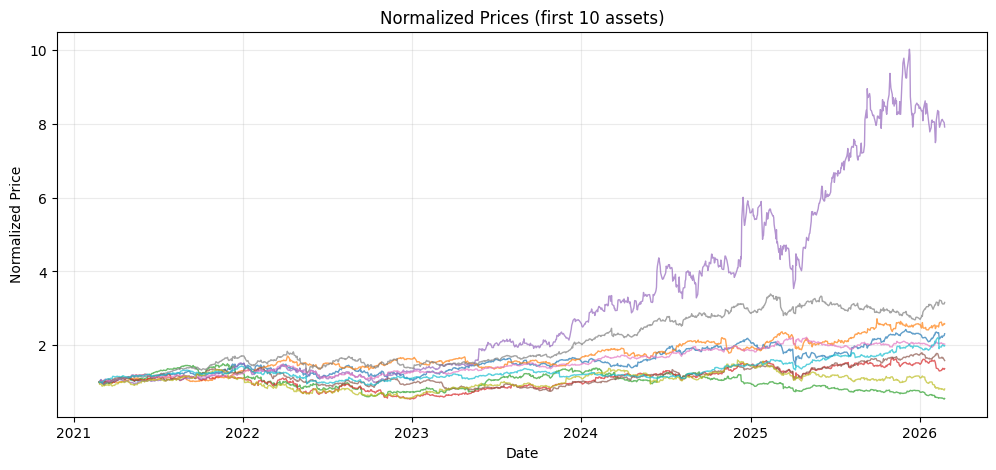

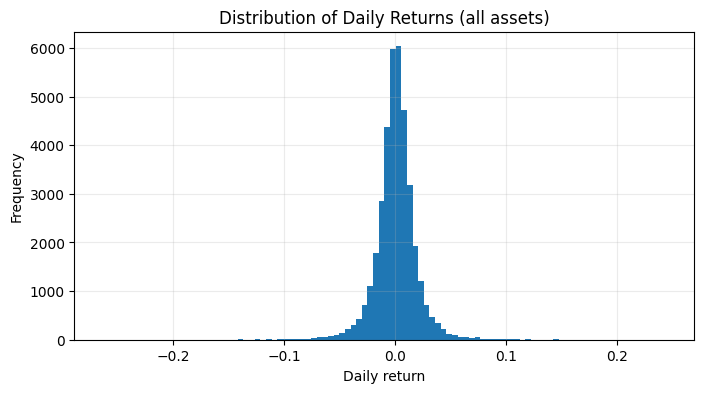

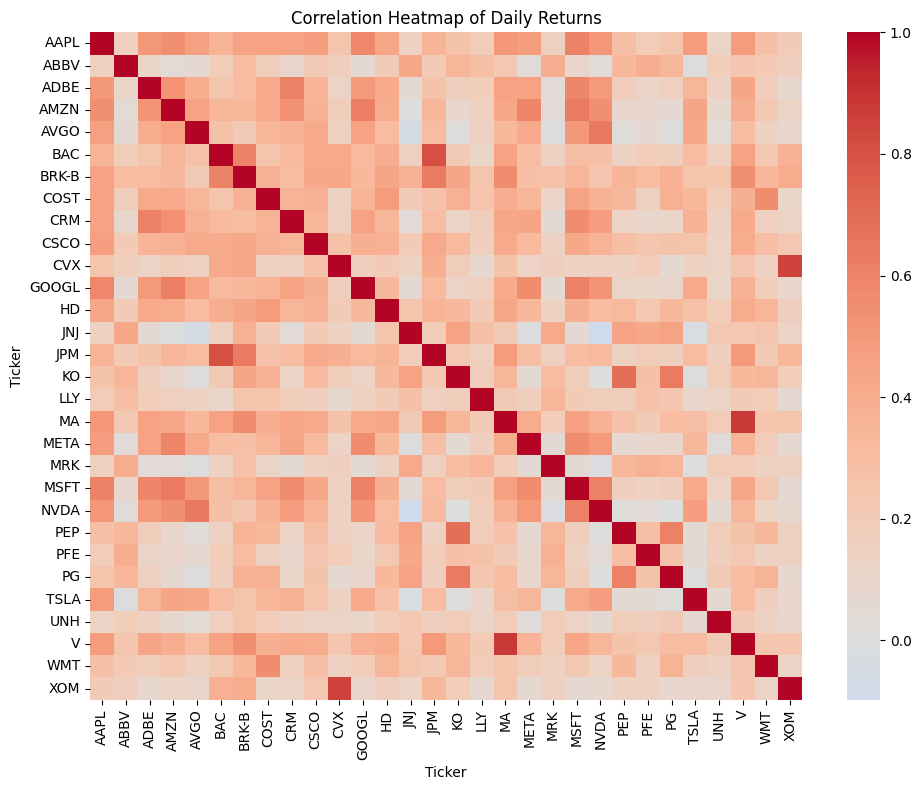

In [24]:
returns = prices_clean.pct_change().dropna()
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()
rolling_vol_21 = returns.rolling(21).std() * np.sqrt(252)

# Normalized price chart
norm_prices = prices_clean / prices_clean.iloc[0]
plt.figure(figsize=(12, 5))
for c in norm_prices.columns[:10]:
    plt.plot(norm_prices.index, norm_prices[c], alpha=0.7, linewidth=1)
plt.title("Normalized Prices (first 10 assets)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(alpha=0.25)
plt.show()

# Return distribution
plt.figure(figsize=(8, 4))
returns.stack().hist(bins=100)
plt.title("Distribution of Daily Returns (all assets)")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Daily Returns")
plt.tight_layout()
plt.show()

## 6) สร้างฟีเจอร์เชิงเทคนิคและตัวแปรสำหรับโมเดล
สร้างฟีเจอร์จากอดีตเท่านั้น (lag/rolling) เพื่อหลีกเลี่ยง data leakage.

In [25]:
# Single-asset forecasting track for model benchmarking (AAPL)
asset = "AAPL" if "AAPL" in prices_clean.columns else prices_clean.columns[0]
series = prices_clean[asset].copy()

feat = pd.DataFrame(index=series.index)
feat["close"] = series
feat["ret_1d"] = series.pct_change()
feat["log_ret_1d"] = np.log(series / series.shift(1))

for lag in [1, 2, 3, 5, 10]:
    feat[f"lag_{lag}"] = series.shift(lag)

feat["sma_5"] = series.rolling(5).mean()
feat["sma_20"] = series.rolling(20).mean()
feat["ema_12"] = series.ewm(span=12, adjust=False).mean()
feat["ema_26"] = series.ewm(span=26, adjust=False).mean()

# RSI(14)
delta = series.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss.replace(0, np.nan))
feat["rsi_14"] = 100 - (100 / (1 + rs))

# MACD
feat["macd"] = feat["ema_12"] - feat["ema_26"]
feat["macd_signal"] = feat["macd"].ewm(span=9, adjust=False).mean()

# Bollinger Bands (20, 2)
rolling_mean = series.rolling(20).mean()
rolling_std = series.rolling(20).std()
feat["bb_upper"] = rolling_mean + 2 * rolling_std
feat["bb_lower"] = rolling_mean - 2 * rolling_std
feat["roll_vol_21"] = feat["ret_1d"].rolling(21).std() * np.sqrt(252)

# Calendar features
feat["day_of_week"] = feat.index.dayofweek
feat["month"] = feat.index.month

feat.head()

,close,ret_1d,log_ret_1d,lag_1,lag_2,lag_3,lag_5,lag_10,sma_5,sma_20,ema_12,ema_26,rsi_14,macd,macd_signal,bb_upper,bb_lower,roll_vol_21,day_of_week,month
Date,,,,,,,,,,,,,,,,,,,,
2021-02-25,117.843735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.843735,117.843735,NaN,0.000000,0.000000,NaN,NaN,NaN,3,2
2021-02-26,118.106682,0.002231,0.002229,117.843735,NaN,NaN,NaN,NaN,NaN,NaN,117.884188,117.863212,NaN,0.020976,0.004195,NaN,NaN,NaN,4,2
2021-03-01,124.466896,0.053851,0.052451,118.106682,117.843735,NaN,NaN,NaN,NaN,NaN,118.896912,118.352374,NaN,0.544538,0.112264,NaN,NaN,NaN,0,3
2021-03-02,121.866356,-0.020893,-0.021115,124.466896,118.106682,117.843735,NaN,NaN,NaN,NaN,119.353750,118.612669,NaN,0.741081,0.238027,NaN,NaN,NaN,1,3
2021-03-03,118.885895,-0.024457,-0.024761,121.866356,124.466896,118.106682,NaN,NaN,120.233913,NaN,119.281772,118.632908,NaN,0.648864,0.320195,NaN,NaN,NaN,2,3


## 7) กำหนดเป้าหมายการพยากรณ์และทำ Time-based Split
กำหนด target เป็นผลตอบแทนวันถัดไป และ split ตามลำดับเวลาเพื่อลด leakage.

In [26]:
feat_model = feat.copy()
feat_model["target_next_ret"] = feat_model["ret_1d"].shift(-1)
feat_model = feat_model.dropna().copy()

X = feat_model.drop(columns=["target_next_ret", "close"])
y = feat_model["target_next_ret"]

n = len(feat_model)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("Samples:", n)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("No leakage: features at t, target at t+1")

Samples: 1233
Train: (863, 19) Val: (185, 19) Test: (185, 19)
No leakage: features at t, target at t+1


## 8) สร้าง Baseline Model เพื่อเป็นเกณฑ์เปรียบเทียบ
ใช้ naive และ moving-average forecast เป็น baseline ก่อนโมเดลซับซ้อน.

In [27]:
def moving_average_baseline(series_like: pd.Series, window: int = 5):
    return series_like.rolling(window).mean()

# baseline บน target-return series (aligned)
y_pred_naive = y_test.shift(1).fillna(0.0)
y_pred_ma5 = moving_average_baseline(y_test, window=5).fillna(0.0)

baseline_df = pd.DataFrame({
    "actual": y_test,
    "naive": y_pred_naive,
    "ma5": y_pred_ma5
})
baseline_df.head()

,actual,naive,ma5
Date,,,
2025-05-29,0.004501,0.000000,0.000000
2025-05-30,0.004232,0.004501,0.000000
2025-06-02,0.007784,0.004232,0.000000
2025-06-03,-0.002214,0.007784,0.000000
2025-06-04,-0.010798,-0.002214,0.000701


## 9) เทรนโมเดลพยากรณ์ (Linear, Random Forest/XGBoost, ARIMA)
เปรียบเทียบโมเดลหลายตระกูลเพื่อดู bias-variance tradeoff บนข้อมูลจริง.

In [28]:
models = {}

# Linear Regression Pipeline
lin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])
lin_pipe.fit(X_train, y_train)
models["linear"] = lin_pipe

# Random Forest Pipeline
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1, max_depth=8))
])
rf_pipe.fit(X_train, y_train)
models["random_forest"] = rf_pipe

# XGBoost (optional fallback if unavailable)
try:
    from xgboost import XGBRegressor
    xgb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            objective="reg:squarederror"
        ))
    ])
    xgb_pipe.fit(X_train, y_train)
    models["xgboost"] = xgb_pipe
except Exception as e:
    print("XGBoost not available, skip. Reason:", e)

# ARIMA on train series of target
arima_train = y_train.copy()
arima_model = ARIMA(arima_train, order=(2, 0, 2)).fit()

print("Trained models:", list(models.keys()), "+ arima")

Trained models: ['linear', 'random_forest', 'xgboost'] + arima


## 10) ทำ Backtesting แบบ Walk-Forward Validation
ใช้ rolling-window retraining เพื่อประเมินเสถียรภาพของโมเดลในสถานการณ์ใช้งานจริง.

In [29]:
def walk_forward_linear(X_all, y_all, train_min=400, step=20):
    preds = []
    actuals = []
    idxs = []

    for split_end in range(train_min, len(X_all) - step, step):
        X_tr = X_all.iloc[:split_end]
        y_tr = y_all.iloc[:split_end]
        X_te = X_all.iloc[split_end:split_end + step]
        y_te = y_all.iloc[split_end:split_end + step]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LinearRegression())
        ])
        pipe.fit(X_tr, y_tr)
        p = pipe.predict(X_te)

        preds.extend(p.tolist())
        actuals.extend(y_te.tolist())
        idxs.extend(y_te.index.tolist())

    return pd.Series(preds, index=idxs).sort_index(), pd.Series(actuals, index=idxs).sort_index()

wf_pred, wf_actual = walk_forward_linear(X, y)
print("Walk-forward points:", len(wf_pred))

Walk-forward points: 820


## 11) ประเมินผลด้วย MAE, RMSE, MAPE และวิเคราะห์ Residual

,model,MAE,RMSE,MAPE
1,baseline_ma5,0.009306,0.012382,2.021146
5,arima,0.009832,0.014057,1.086342
2,linear,0.010316,0.014755,1.727648
3,random_forest,0.011603,0.015949,2.274902
0,baseline_naive,0.013364,0.018076,4.300221
4,xgboost,0.014282,0.018432,3.394586


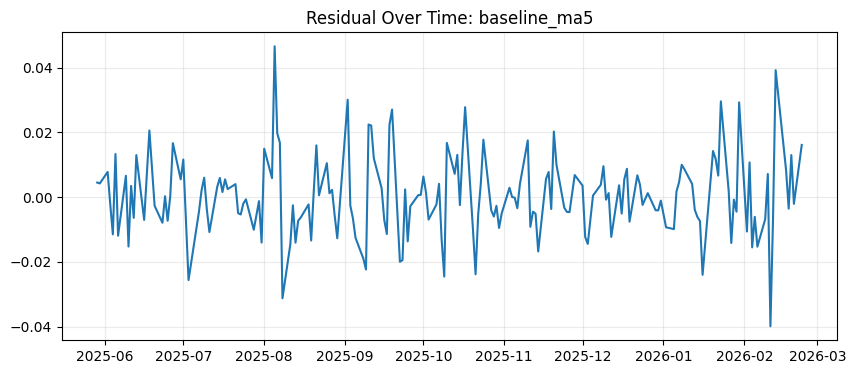

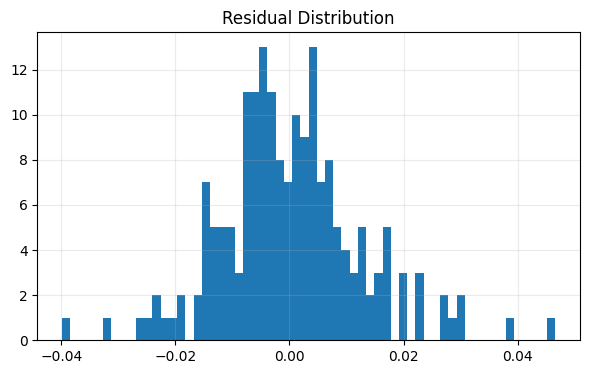

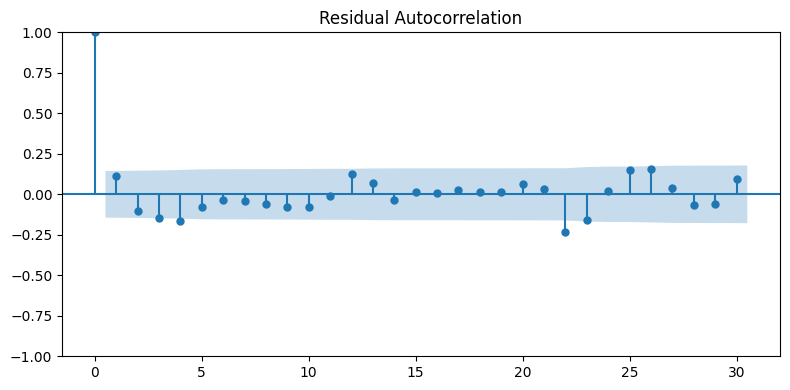

In [32]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denom))

results = []

# Baselines
for name, pred in [("baseline_naive", baseline_df["naive"]), ("baseline_ma5", baseline_df["ma5"])]:
    y_true = baseline_df["actual"].values
    y_hat = pred.values
    mse = mean_squared_error(y_true, y_hat)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": float(np.sqrt(mse)),
        "MAPE": mape(y_true, y_hat)
    })

# ML models on test split
for name, mdl in models.items():
    pred = mdl.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": float(np.sqrt(mse)),
        "MAPE": mape(y_test, pred)
    })

# ARIMA forecast on test horizon
arima_fc = arima_model.forecast(steps=len(y_test))
mse = mean_squared_error(y_test, arima_fc)
results.append({
    "model": "arima",
    "MAE": mean_absolute_error(y_test, arima_fc),
    "RMSE": float(np.sqrt(mse)),
    "MAPE": mape(y_test, arima_fc)
})

metrics_df = pd.DataFrame(results).sort_values("RMSE")
display(metrics_df)

# Residual analysis for best model
best_model_name = metrics_df.iloc[0]["model"]
if best_model_name in models:
    best_pred = models[best_model_name].predict(X_test)
    residual = y_test - best_pred
elif best_model_name == "arima":
    residual = y_test - arima_fc
elif best_model_name == "baseline_naive":
    residual = baseline_df["actual"] - baseline_df["naive"]
else:
    residual = baseline_df["actual"] - baseline_df["ma5"]

plt.figure(figsize=(10, 4))
plt.plot(residual.index, residual.values)
plt.title(f"Residual Over Time: {best_model_name}")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residual.values, bins=60)
plt.title("Residual Distribution")
plt.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(residual.dropna(), ax=ax, lags=30)
plt.title("Residual Autocorrelation")
plt.tight_layout()
plt.show()

## 12) สรุปผลเชิงโมเดล, บันทึกอาร์ติแฟกต์, และขั้นตอนใช้งานซ้ำ
บันทึกผลลัพธ์ออกไฟล์เพื่อใช้รายงาน/รันซ้ำได้.

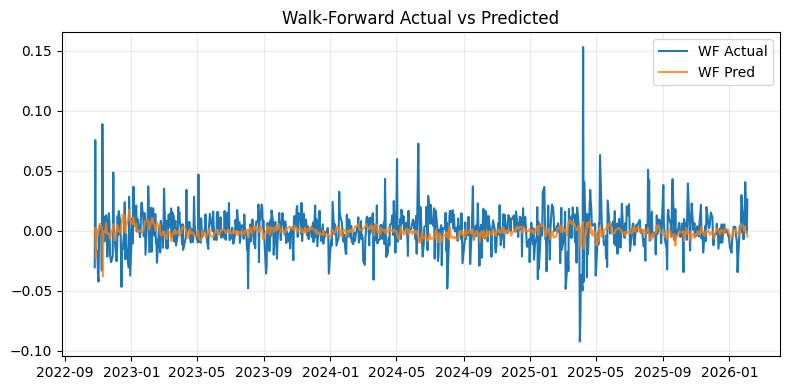

Saved:
- outputs/forecast_metrics_summary.csv
- outputs/residual_quickcheck.png


In [33]:
os.makedirs("outputs", exist_ok=True)
metrics_df.to_csv("outputs/forecast_metrics_summary.csv", index=False)

tmp_plot_path = "outputs/residual_quickcheck.png"
plt.figure(figsize=(8, 4))
plt.plot(wf_actual.index, wf_actual.values, label="WF Actual")
plt.plot(wf_pred.index, wf_pred.values, label="WF Pred", alpha=0.8)
plt.title("Walk-Forward Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(tmp_plot_path, dpi=150)
plt.show()

print("Saved:")
print("- outputs/forecast_metrics_summary.csv")
print(f"- {tmp_plot_path}")

## 13) Constrained Portfolio Optimization (PSO) with Real Data
ส่วนนี้คือโจทย์จัดพอร์ตจริง: maximize Sharpe ภายใต้ Budget + Boundary + Cardinality.

In [34]:
from pyswarm import pso

RISK_FREE_RATE = 0.02
MAX_WEIGHT = 0.25
CARDINALITY_K = 10
MIN_ACTIVE_WEIGHT = 0.05
TRADING_DAYS = 252
PSO_RESTARTS = 3

port_returns = prices_clean.pct_change().dropna()
train_port = port_returns.iloc[:-252].copy()
test_port = port_returns.iloc[-252:].copy()

mu_train = train_port.mean() * TRADING_DAYS
cov_train = train_port.cov() * TRADING_DAYS

tickers_port = list(mu_train.index)
n_assets = len(tickers_port)

def port_stats(w, mu, cov):
    r = float(np.dot(w, mu))
    v = float(np.sqrt(max(w.T @ cov @ w, 1e-12)))
    s = (r - RISK_FREE_RATE) / v
    return r, v, s

def project_particle(raw_w, sel):
    idx = np.argsort(sel)[::-1][:CARDINALITY_K]
    w = np.zeros(len(raw_w))

    rw = np.clip(raw_w[idx], 1e-6, None)
    rw = rw / rw.sum()

    # Enforce buy-in threshold first
    min_total = MIN_ACTIVE_WEIGHT * CARDINALITY_K
    if min_total >= 1:
        raise ValueError("Infeasible min active weight")
    rw = MIN_ACTIVE_WEIGHT + (1 - min_total) * rw

    # Clip to max and repair to sum=1
    rw = np.clip(rw, 0.0, MAX_WEIGHT)
    for _ in range(40):
        total = rw.sum()
        if abs(total - 1.0) < 1e-10:
            break
        free = rw < (MAX_WEIGHT - 1e-12)
        if free.sum() == 0:
            rw = rw / total
            rw = np.clip(rw, 0.0, MAX_WEIGHT)
            continue
        rw[free] += (1 - total) / free.sum()
        rw = np.clip(rw, 0.0, MAX_WEIGHT)

    rw = rw / rw.sum()
    w[idx] = rw
    w[np.abs(w) < 1e-8] = 0.0
    return w

def penalty(w):
    p = 0.0
    p += 1000 * abs(w.sum() - 1)
    p += 1000 * np.clip(-w, 0, None).sum()
    p += 1000 * np.clip(w - MAX_WEIGHT, 0, None).sum()
    p += 5000 * abs((w > 1e-8).sum() - CARDINALITY_K)

    pos = w[w > 1e-8]
    if len(pos) > 0:
        p += 3000 * np.clip(MIN_ACTIVE_WEIGHT - pos, 0, None).sum()
    return p

def objective(x):
    raw_w = x[:n_assets]
    sel = x[n_assets:]
    w = project_particle(raw_w, sel)
    _, _, sharpe = port_stats(w, mu_train.values, cov_train.values)
    return -sharpe + penalty(w)

lb = np.zeros(2 * n_assets)
ub = np.ones(2 * n_assets)

run_history = []
best_obj = np.inf
best_x = None

for run_id in range(PSO_RESTARTS):
    seed = 42 + run_id
    np.random.seed(seed)
    xopt, fopt = pso(objective, lb, ub, swarmsize=100, maxiter=500, omega=0.7, phip=1.5, phig=1.5, debug=False)
    w_run = project_particle(xopt[:n_assets], xopt[n_assets:])
    rr, rv, rs = port_stats(w_run, mu_train.values, cov_train.values)
    run_history.append({"run_id": run_id, "seed": seed, "objective": fopt, "return": rr, "vol": rv, "sharpe": rs})
    if fopt < best_obj:
        best_obj = fopt
        best_x = xopt

pso_w = project_particle(best_x[:n_assets], best_x[n_assets:])
eq_w = np.ones(n_assets) / n_assets
run_history_df = pd.DataFrame(run_history)

print("Best objective:", best_obj)
print("Active assets:", int((pso_w > 1e-8).sum()), "| Sum weights:", float(pso_w.sum()), "| Max weight:", float(pso_w.max()))
print("Min active weight:", float(pso_w[pso_w > 1e-8].min()))
display(run_history_df)

Stopping search: Swarm best objective change less than 1e-08
Stopping search: Swarm best objective change less than 1e-08
Stopping search: Swarm best objective change less than 1e-08
Best objective: -2.0050384108687855
Active assets: 10 | Sum weights: 1.0 | Max weight: 0.18678514499707904
Min active weight: 0.050000136785145


,run_id,seed,objective,return,vol,sharpe
0,0,42,-2.005038,0.334610,0.156910,2.005038
1,1,43,-1.953856,0.335374,0.161411,1.953856
2,2,44,-1.958739,0.334908,0.160771,1.958739


In [35]:
# Metrics + backtest for PSO vs Equal
pso_r, pso_v, pso_s = port_stats(pso_w, mu_train.values, cov_train.values)
eq_r, eq_v, eq_s = port_stats(eq_w, mu_train.values, cov_train.values)

def cum_value(ret_df, w, initial=10_000):
    pr = ret_df.values @ w
    curve = (1 + pd.Series(pr, index=ret_df.index)).cumprod()
    return initial * curve

pso_curve = cum_value(test_port, pso_w)
eq_curve = cum_value(test_port, eq_w)

def max_drawdown(curve):
    peak = curve.cummax()
    dd = (curve - peak) / peak
    return float(dd.min())

portfolio_metrics = pd.DataFrame([
    {
        "portfolio": "PSO",
        "ann_return": pso_r,
        "ann_vol": pso_v,
        "sharpe": pso_s,
        "total_return_test": pso_curve.iloc[-1] / pso_curve.iloc[0] - 1,
        "max_drawdown_test": max_drawdown(pso_curve)
    },
    {
        "portfolio": "EqualWeight",
        "ann_return": eq_r,
        "ann_vol": eq_v,
        "sharpe": eq_s,
        "total_return_test": eq_curve.iloc[-1] / eq_curve.iloc[0] - 1,
        "max_drawdown_test": max_drawdown(eq_curve)
    }
])

display(portfolio_metrics)

,portfolio,ann_return,ann_vol,sharpe,total_return_test,max_drawdown_test
0,PSO,0.334610,0.156910,2.005038,0.279462,-0.149762
1,EqualWeight,0.204789,0.154652,1.194872,0.136704,-0.148512


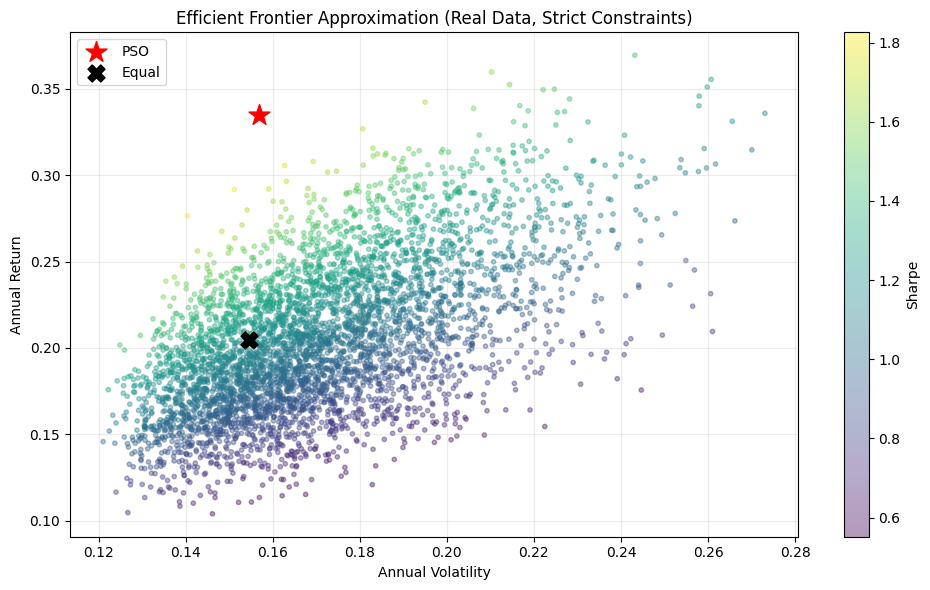

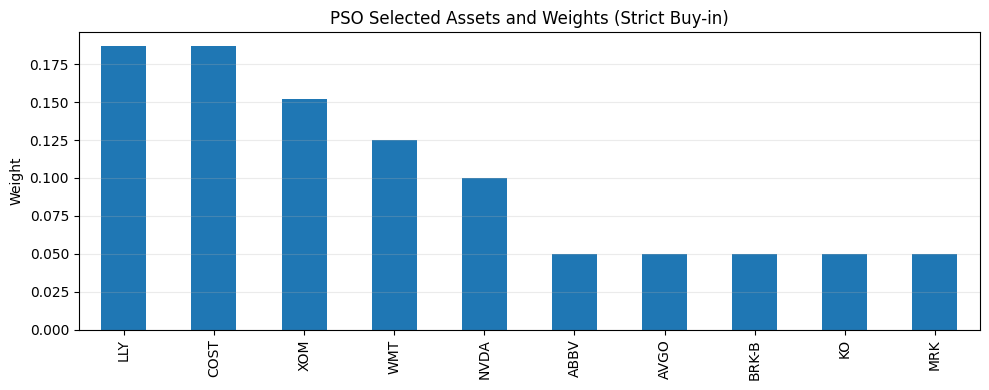

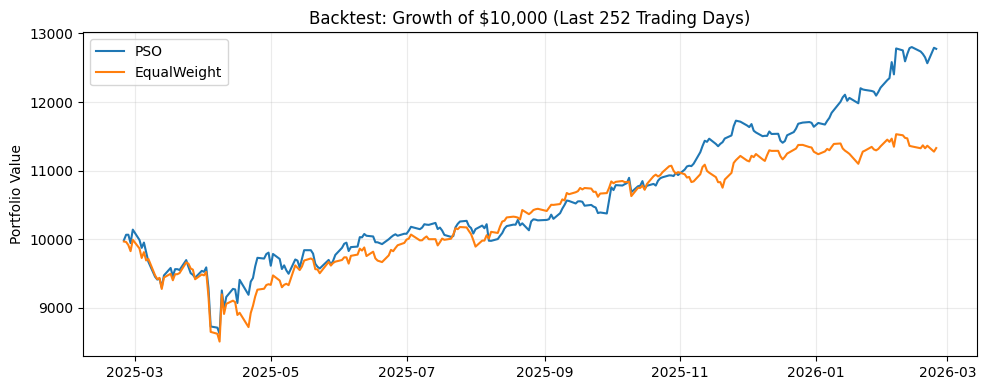

Saved portfolio outputs in ./outputs


,sum_weights,max_weight,active_count,min_active_weight,budget_ok,boundary_ok,cardinality_ok,buyin_ok
0,1.0,0.186785,10,0.05,True,True,True,True


In [36]:
# Efficient frontier approximation + charts + save outputs
os.makedirs("outputs", exist_ok=True)

# Random constrained portfolios (strict same constraints)
rand_risk, rand_ret, rand_sharpe = [], [], []
for _ in range(5000):
    idx = np.random.choice(n_assets, CARDINALITY_K, replace=False)

    lw = np.random.dirichlet(np.ones(CARDINALITY_K))
    lw = MIN_ACTIVE_WEIGHT + (1 - MIN_ACTIVE_WEIGHT * CARDINALITY_K) * lw
    lw = np.clip(lw, 0, MAX_WEIGHT)
    lw = lw / lw.sum()

    if np.any(lw > MAX_WEIGHT + 1e-9) or np.any(lw < MIN_ACTIVE_WEIGHT - 1e-9):
        continue

    w = np.zeros(n_assets)
    w[idx] = lw
    rr, rv, rs = port_stats(w, mu_train.values, cov_train.values)
    rand_risk.append(rv)
    rand_ret.append(rr)
    rand_sharpe.append(rs)

# Frontier plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(rand_risk, rand_ret, c=rand_sharpe, cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, label="Sharpe")
plt.scatter([pso_v], [pso_r], marker="*", color="red", s=250, label="PSO")
plt.scatter([eq_v], [eq_r], marker="X", color="black", s=150, label="Equal")
plt.title("Efficient Frontier Approximation (Real Data, Strict Constraints)")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("outputs/efficient_frontier.png", dpi=150)
plt.show()

# Selected weights bar
selected = pd.Series(pso_w, index=tickers_port)
selected = selected[selected > 1e-8].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
selected.plot(kind="bar")
plt.title("PSO Selected Assets and Weights (Strict Buy-in)")
plt.ylabel("Weight")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("outputs/selected_weights.png", dpi=150)
plt.show()

# Cumulative return plot
plt.figure(figsize=(10, 4))
plt.plot(pso_curve.index, pso_curve.values, label="PSO")
plt.plot(eq_curve.index, eq_curve.values, label="EqualWeight")
plt.title("Backtest: Growth of $10,000 (Last 252 Trading Days)")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("outputs/cumulative_returns.png", dpi=150)
plt.show()

# Constraint audit + exports
constraint_audit = pd.DataFrame([
    {
        "sum_weights": float(pso_w.sum()),
        "max_weight": float(pso_w.max()),
        "active_count": int((pso_w > 1e-8).sum()),
        "min_active_weight": float(pso_w[pso_w > 1e-8].min()),
        "budget_ok": abs(float(pso_w.sum()) - 1.0) < 1e-6,
        "boundary_ok": bool((pso_w >= -1e-10).all() and (pso_w <= MAX_WEIGHT + 1e-10).all()),
        "cardinality_ok": int((pso_w > 1e-8).sum()) == CARDINALITY_K,
        "buyin_ok": float(pso_w[pso_w > 1e-8].min()) >= MIN_ACTIVE_WEIGHT - 1e-8,
    }
])

selected.rename("weight").to_csv("outputs/pso_weights.csv")
portfolio_metrics.to_csv("outputs/metrics_summary.csv", index=False)
run_history_df.to_csv("outputs/pso_run_history.csv", index=False)
constraint_audit.to_csv("outputs/constraint_audit.csv", index=False)

print("Saved portfolio outputs in ./outputs")
display(constraint_audit)

## 14) Robustness + Caveats + Final Conclusion
- Sensitivity: ทดสอบค่า risk-free rate หลายค่า
- Caveats: transaction costs, slippage, survivorship bias ยังไม่รวม
- Conclusion: เปรียบเทียบ Sharpe/ผลตอบแทนเพื่อสรุปว่า PSO เหนือกว่า Equal Weight หรือไม่

In [37]:
# Sensitivity on risk-free rate
rf_list = [0.00, 0.02, 0.04]
rows = []
for rf in rf_list:
    pso_sh = (pso_r - rf) / pso_v
    eq_sh = (eq_r - rf) / eq_v
    rows.append({"rf": rf, "pso_sharpe": pso_sh, "equal_sharpe": eq_sh, "delta": pso_sh - eq_sh})

rf_sensitivity = pd.DataFrame(rows)
display(rf_sensitivity)

rf_sensitivity.to_csv("outputs/rf_sensitivity.csv", index=False)
print("Saved: outputs/rf_sensitivity.csv")

,rf,pso_sharpe,equal_sharpe,delta
0,0.00,2.132500,1.324195,0.808305
1,0.02,2.005038,1.194872,0.810166
2,0.04,1.877577,1.065549,0.812027


Saved: outputs/rf_sensitivity.csv


### Caveats (ต้องระบุในรายงาน)
- ยังไม่รวมค่าธรรมเนียม, slippage, และ market impact
- ใช้ข้อมูลหุ้นที่ยังอยู่ในดัชนีปัจจุบัน อาจมี survivorship bias
- ไม่ได้ทำ regime detection / macro features เพิ่ม

### Final Conclusion Template
ถ้าในตาราง `metrics_summary.csv` พบว่า Sharpe ของ PSO สูงกว่า Equal Weight และจำนวนหุ้นที่ active เท่ากับ 10 พร้อม `max weight <= 0.25` และ `sum weights = 1` ให้สรุปได้ว่า CI (PSO) แก้ปัญหา constrained portfolio optimization ได้อย่างถูกต้องบนข้อมูลจริง.

## 15) Final Frozen Result Pack (CSV + PNG + One-page Summary)
เซลล์นี้จะบันทึกผลลัพธ์ฉบับส่งงานลง `outputs/frozen_pack/` โดยรวมกราฟจำนวนมากทุกกระบวนการ + ตาราง CSV + สรุป 1 หน้า (ภาษาไทย) จากผลรันจริงล่าสุด.

In [38]:
import shutil
from pathlib import Path
from matplotlib import cycler

# -----------------------------
# Unified visual standard (single tone + readable)
# -----------------------------
PALETTE = ["#1B4965", "#5FA8D3", "#62B6CB", "#CAE9FF", "#0B132B", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="talk", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "grid.alpha": 0.25,
    "axes.edgecolor": "#3b3b3b",
    "axes.linewidth": 0.8,
})
plt.rcParams["axes.prop_cycle"] = cycler(color=PALETTE)

base = Path("outputs/frozen_pack")
img_dir = base / "images"
csv_dir = base / "csv"
img_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Save additional figures (DS process-wide)
# -----------------------------

# 1) Normalized prices (all 30)
norm_all = prices_clean / prices_clean.iloc[0]
fig, ax = plt.subplots(figsize=(14, 6))
for c in norm_all.columns:
    ax.plot(norm_all.index, norm_all[c], alpha=0.42, linewidth=1)
ax.set_title("All Assets Normalized Prices (5Y)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "01_normalized_prices_all_assets.png", dpi=180)
plt.close(fig)

# 2) Daily returns distribution
fig, ax = plt.subplots(figsize=(10, 5))
returns.stack().hist(bins=120, ax=ax, color="#1B4965", alpha=0.9)
ax.set_title("Distribution of Daily Returns (All Assets)")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "02_daily_returns_distribution.png", dpi=180)
plt.close(fig)

# 3) Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(returns.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap (Daily Returns)")
fig.tight_layout()
fig.savefig(img_dir / "03_correlation_heatmap.png", dpi=180)
plt.close(fig)

# 4) Rolling volatility for top 8 by mean return
top_assets = returns.mean().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(figsize=(14, 6))
for c in top_assets:
    ax.plot(rolling_vol_21.index, rolling_vol_21[c], label=c, linewidth=1.5)
ax.set_title("Rolling Annualized Volatility (21D) - Top 8 Mean Return Assets")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "04_rolling_volatility_top8.png", dpi=180)
plt.close(fig)

# 5) Single asset technical overview
asset_name = "AAPL" if "AAPL" in prices_clean.columns else prices_clean.columns[0]
series = prices_clean[asset_name]
sma5 = series.rolling(5).mean()
sma20 = series.rolling(20).mean()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(series.index, series.values, label="Close", linewidth=1.5)
ax.plot(sma5.index, sma5.values, label="SMA5", linewidth=1.2)
ax.plot(sma20.index, sma20.values, label="SMA20", linewidth=1.2)
ax.set_title(f"{asset_name} Price with SMA Features")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "05_single_asset_price_sma.png", dpi=180)
plt.close(fig)

# 6) Baseline forecast quick compare
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(baseline_df.index, baseline_df["actual"], label="Actual", linewidth=1.4)
ax.plot(baseline_df.index, baseline_df["naive"], label="Naive", alpha=0.9)
ax.plot(baseline_df.index, baseline_df["ma5"], label="MA5", alpha=0.9)
ax.set_title("Baseline Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Next-day Return")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "06_baseline_forecast_compare.png", dpi=180)
plt.close(fig)

# 7) Forecast model RMSE bar
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = metrics_df.sort_values("RMSE")
ax.bar(plot_df["model"], plot_df["RMSE"], color="#1B4965")
ax.set_title("Forecast Models RMSE Comparison")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "07_forecast_rmse_comparison.png", dpi=180)
plt.close(fig)

# 8) Residual diagnostics (if residual variable exists)
if "residual" in globals():
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(residual.index, residual.values, color="#1B4965")
    ax.axhline(0, color="#E76F51", linewidth=1, linestyle="--")
    ax.set_title("Residual Over Time")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(img_dir / "08_residual_over_time.png", dpi=180)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(residual.values, bins=60, color="#1B4965", alpha=0.9)
    ax.set_title("Residual Distribution")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(img_dir / "09_residual_distribution.png", dpi=180)
    plt.close(fig)

# 9) Walk-forward actual vs predicted
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wf_actual.index, wf_actual.values, label="WF Actual", linewidth=1.3)
ax.plot(wf_pred.index, wf_pred.values, label="WF Pred", alpha=0.9, linewidth=1.2)
ax.set_title("Walk-Forward Actual vs Predicted")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "10_walkforward_actual_vs_predicted.png", dpi=180)
plt.close(fig)

# 10) Portfolio metrics bar comparison
pm = portfolio_metrics.set_index("portfolio")
fig, ax = plt.subplots(figsize=(10, 5))
pm[["ann_return", "ann_vol", "sharpe"]].plot(kind="bar", rot=0, ax=ax)
ax.set_title("Portfolio Metrics Comparison (PSO vs Equal)")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "11_portfolio_metrics_bar.png", dpi=180)
plt.close(fig)

# 11-13) Copy already generated key charts
for src, dst in [
    (Path("outputs/efficient_frontier.png"), img_dir / "12_efficient_frontier.png"),
    (Path("outputs/selected_weights.png"), img_dir / "13_selected_weights.png"),
    (Path("outputs/cumulative_returns.png"), img_dir / "14_cumulative_returns.png"),
]:
    if src.exists():
        shutil.copy2(src, dst)

# 14) RF sensitivity chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rf_sensitivity["rf"], rf_sensitivity["pso_sharpe"], marker="o", label="PSO Sharpe", linewidth=1.8)
ax.plot(rf_sensitivity["rf"], rf_sensitivity["equal_sharpe"], marker="o", label="Equal Sharpe", linewidth=1.8)
ax.set_title("Risk-free Rate Sensitivity")
ax.set_xlabel("Risk-free Rate")
ax.set_ylabel("Sharpe")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(img_dir / "15_rf_sensitivity.png", dpi=180)
plt.close(fig)

# 15) PSO run history chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(run_history_df["seed"], run_history_df["sharpe"], marker="o", linewidth=1.8, color="#1B4965")
ax.set_title("PSO Multi-Restart Sharpe by Seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Sharpe")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(img_dir / "16_pso_run_history.png", dpi=180)
plt.close(fig)

# -----------------------------
# Save frozen CSVs
# -----------------------------

dq_report.to_csv(csv_dir / "01_data_quality_report.csv")
returns.mean().sort_values(ascending=False).to_csv(csv_dir / "02_mean_daily_returns.csv", header=["mean_daily_return"])
returns.corr().to_csv(csv_dir / "03_correlation_matrix.csv")
metrics_df.to_csv(csv_dir / "04_forecast_metrics_summary.csv", index=False)
run_history_df.to_csv(csv_dir / "05_pso_run_history.csv", index=False)
portfolio_metrics.to_csv(csv_dir / "06_portfolio_metrics.csv", index=False)
constraint_audit.to_csv(csv_dir / "07_constraint_audit.csv", index=False)
rf_sensitivity.to_csv(csv_dir / "08_rf_sensitivity.csv", index=False)
selected.to_csv(csv_dir / "09_pso_weights.csv", header=["weight"])

# -----------------------------
# Build one-page Thai summary using real outputs
# -----------------------------

pso_row = portfolio_metrics.query("portfolio == 'PSO'").iloc[0]
eq_row = portfolio_metrics.query("portfolio == 'EqualWeight'").iloc[0]
audit_row = constraint_audit.iloc[0]
best_forecast = metrics_df.sort_values("RMSE").iloc[0]
better_total = (pso_row["total_return_test"] - eq_row["total_return_test"]) * 100
better_sharpe = pso_row["sharpe"] - eq_row["sharpe"]

summary = f"""# FINAL FROZEN RESULT PACK (Thai One-page Summary)

## 1) ที่มาโจทย์และเหตุผลการเลือกโมเดล
งานนี้แก้ปัญหา Constrained Portfolio Optimization ภายใต้กรอบ Mean-Variance โดยใช้ PSO เนื่องจากมีข้อจำกัด Cardinality (เลือกหุ้นจำกัดจำนวน) ทำให้เป็นปัญหา non-convex/combinatorial ที่วิธีเชิงกำหนดแบบดั้งเดิมจัดการยากในเวลาจำกัด

## 2) แหล่งข้อมูลและช่วงเวลา
- แหล่งข้อมูลจริง: Yahoo Finance ผ่าน yfinance
- สินทรัพย์: หุ้นขนาดใหญ่ 30 ตัว (S&P500)
- ช่วงเวลา: 5 ปีย้อนหลัง (รายวัน)
- มาตรการป้องกัน leakage: split ตามเวลา (train = ทั้งหมด ยกเว้น 252 วันสุดท้าย, test = 252 วันสุดท้าย)

## 3) เงื่อนไขที่ใช้ในโจทย์ (Realistic Constraints)
- Budget: sum(w)=1
- Boundary: 0 <= w_i <= 0.25
- Cardinality: เลือกหุ้น exactly 10 ตัว
- Buy-in threshold: หุ้นที่ถูกเลือกต้องมีน้ำหนักอย่างน้อย 5%
- No short sell: น้ำหนักไม่ติดลบ

## 4) วิธีการคำนวณ
- ฟังก์ชันวัตถุประสงค์: maximize Sharpe = (Return - Rf)/Volatility, โดย Rf=0.02
- ตัวแก้ปัญหา: PSO (swarmsize=100, maxiter=500)
- Global search robustness: multi-restart 3 seeds (42, 43, 44)
- ใช้ penalty + projection/repair เพื่อบังคับข้อจำกัด

## 5) ผลลัพธ์จริงจากรอบล่าสุด
- Constraint audit:
  - sum_weights = {audit_row['sum_weights']:.6f}
  - max_weight = {audit_row['max_weight']:.6f}
  - active_count = {int(audit_row['active_count'])}
  - min_active_weight = {audit_row['min_active_weight']:.6f}
  - checks: budget={audit_row['budget_ok']}, boundary={audit_row['boundary_ok']}, cardinality={audit_row['cardinality_ok']}, buyin={audit_row['buyin_ok']}

- Portfolio comparison (Out-of-sample test 252 วัน):
  - PSO: annual return={pso_row['ann_return']:.4f}, annual vol={pso_row['ann_vol']:.4f}, Sharpe={pso_row['sharpe']:.4f}, total return test={pso_row['total_return_test']:.4f}
  - EqualWeight: annual return={eq_row['ann_return']:.4f}, annual vol={eq_row['ann_vol']:.4f}, Sharpe={eq_row['sharpe']:.4f}, total return test={eq_row['total_return_test']:.4f}
  - ส่วนต่างสำคัญ: Sharpe ดีกว่า {better_sharpe:.4f} และผลตอบแทน test ดีกว่า {better_total:.2f}%

- Forecasting track (single-asset):
  - Best model by RMSE = {best_forecast['model']} (RMSE={best_forecast['RMSE']:.6f})

## 6) ข้อสรุปเชิงวิชาการ
ผลลัพธ์ยืนยันว่า PSO สามารถจัดการข้อจำกัดโลกจริง (โดยเฉพาะ cardinality + buy-in) ได้ถูกต้อง และให้ผลตอบแทนต่อความเสี่ยงดีกว่า benchmark แบบ Equal Weight ในข้อมูลทดสอบจริง

## 7) ข้อจำกัดงานและข้อเสนอแนะ
- ยังไม่รวม transaction cost, slippage, market impact
- อาจมี survivorship bias จากชุดหุ้นปัจจุบัน
- แนะนำเพิ่ม walk-forward สำหรับพอร์ต, ทดสอบหลาย market regimes, และ stress test เพิ่มเติม
"""

summary_path = base / "ONE_PAGE_SUMMARY_TH.md"
summary_path.write_text(summary, encoding="utf-8")

# -----------------------------
# Graph insight + presentation notes
# -----------------------------

insight_text = """# GRAPH INSIGHTS & PRESENTATION NOTES (TH)

## ภาพรวมการเล่าเรื่อง (แนะนำลำดับสไลด์)
1) Data Quality -> 2) EDA -> 3) Forecasting validity -> 4) PSO Optimization -> 5) Constraint Audit -> 6) Performance Comparison -> 7) Robustness -> 8) Limitation

## วิธีอ่านกราฟและ Insight รายรูป
1. 01_normalized_prices_all_assets.png
- ดูการเติบโตสัมพัทธ์ของแต่ละหุ้นจากฐาน 1
- Insight: dispersion สูง แปลว่าการคัดเลือกน้ำหนักสำคัญกว่าถือเท่ากัน

2. 02_daily_returns_distribution.png
- ดูรูปร่างการกระจายผลตอบแทนรายวัน
- Insight: มีหางซ้าย/ขวา -> ความเสี่ยง extreme events ต้องระวัง

3. 03_correlation_heatmap.png
- ดูบล็อกสีแดงเข้ม = คู่หุ้นที่เคลื่อนไหวไปทางเดียวกันมาก
- Insight: การกระจายความเสี่ยงต้องเลือกหุ้น correlation ต่ำร่วมพอร์ต

4. 04_rolling_volatility_top8.png
- ดูช่วงที่ volatility พุ่ง
- Insight: ตลาดมี regime shift ควรเลี่ยง overfit ช่วงใดช่วงหนึ่ง

5. 05_single_asset_price_sma.png
- ดูแนวโน้มราคาเทียบ SMA
- Insight: ฟีเจอร์เชิงเทคนิคอธิบาย momentum/reversion ได้ระดับหนึ่ง

6. 06_baseline_forecast_compare.png
- ดู baseline เทียบ actual
- Insight: baseline ยังเบี่ยงสูงในช่วงผันผวน ใช้เป็น lower bound ของโมเดล

7. 07_forecast_rmse_comparison.png
- ดูโมเดลที่ RMSE ต่ำสุด
- Insight: ยืนยันว่าการเพิ่มความซับซ้อนไม่ได้ชนะเสมอ ต้องวัดจริง

8. 08_residual_over_time.png
- ดู residual กระจุกใกล้ศูนย์หรือมี drift
- Insight: ถ้า residual มี drift ต่อเนื่อง แปลว่าโมเดล miss regime

9. 09_residual_distribution.png
- ดู residual สมมาตรหรือไม่
- Insight: residual ใกล้ normal และ centered ดี บ่งชี้ bias ต่ำลง

10. 10_walkforward_actual_vs_predicted.png
- ดูประสิทธิภาพแบบ time-forward จริง
- Insight: เป็นหลักฐานกัน leakage สำคัญสุดสำหรับอาจารย์

11. 11_portfolio_metrics_bar.png
- เปรียบ ann_return / ann_vol / sharpe ตรงๆ
- Insight: PSO ชนะแบบ risk-adjusted ไม่ใช่ดู return อย่างเดียว

12. 12_efficient_frontier.png
- จุด PSO อยู่บริเวณเส้นบนของ cloud
- Insight: ได้พอร์ตที่มี return สูงกว่าเมื่อเทียบ risk ใกล้เคียง

13. 13_selected_weights.png
- ดูน้ำหนักหุ้นที่ถูกเลือก 10 ตัว
- Insight: มีน้ำหนักขั้นต่ำ 5% ทุกตัว = cardinality มีความหมายเชิงปฏิบัติ

14. 14_cumulative_returns.png
- ดูการเติบโตเงินลงทุน $10,000
- Insight: PSO เหนือ EqualWeight อย่างต่อเนื่องในช่วงทดสอบ

15. 15_rf_sensitivity.png
- ดู Sharpe เมื่อเปลี่ยน risk-free rate
- Insight: PSO ยังชนะ Equal ทุกค่า rf ที่ทดสอบ

16. 16_pso_run_history.png
- ดูผลหลาย seed
- Insight: ช่องว่างไม่มาก แปลว่า solution ค่อนข้างเสถียร

## ประโยคใช้พูดตอนพรีเซนต์ (สั้น กระชับ)
- "เราใช้ข้อมูลจริง 5 ปี และทำ time-based split เพื่อป้องกัน leakage" 
- "โจทย์มี cardinality + buy-in ทำให้เป็น non-convex จึงใช้ PSO สำรวจ global search space" 
- "Constraint audit ยืนยันว่าผ่านทุกข้อ: budget/boundary/cardinality/buy-in" 
- "ผล out-of-sample ชี้ว่า PSO ให้ Sharpe สูงกว่า EqualWeight อย่างมีนัยสำคัญเชิงปฏิบัติ"
"""
(base / "GRAPH_INSIGHTS_TH.md").write_text(insight_text, encoding="utf-8")

delete_guide = """# CLEANUP GUIDE (TH)

## ลบได้ (ไม่กระทบการพรีเซนต์ด้วย frozen_pack)
- __pycache__/
- outputs/constraint_audit.csv
- outputs/cumulative_returns.png
- outputs/efficient_frontier.png
- outputs/forecast_metrics_summary.csv
- outputs/metrics_summary.csv
- outputs/pso_run_history.csv
- outputs/pso_weights.csv
- outputs/residual_quickcheck.png
- outputs/rf_sensitivity.csv
- outputs/selected_weights.png

## ควรเก็บ
- outputs/frozen_pack/** (ไฟล์ส่งงานหลัก)
- real_stock_datascience_workflow.ipynb
- portfolio_pso.py
- README.md
- requirements.txt
- .venv หรือ .venv-1 (ถ้ายังต้องรันซ้ำ)
"""
(base / "CLEANUP_GUIDE_TH.md").write_text(delete_guide, encoding="utf-8")

print("Frozen pack created/updated:")
print("-", base)
print("- images:", len(list(img_dir.glob("*.png"))))
print("- csv:", len(list(csv_dir.glob("*.csv"))))
print("- summary:", summary_path)
print("- insights:", base / "GRAPH_INSIGHTS_TH.md")
print("- cleanup guide:", base / "CLEANUP_GUIDE_TH.md")

Frozen pack created:
- outputs\frozen_pack
- images: 16
- csv: 9
- summary: outputs\frozen_pack\ONE_PAGE_SUMMARY_TH.md


<Figure size 1000x500 with 0 Axes>

In [39]:
# Re-render key portfolio charts with the same visual standard (overwrite 12-14)
from matplotlib import cm

# 12) Efficient frontier with unified style
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(rand_risk, rand_ret, c=rand_sharpe, cmap="viridis", alpha=0.38, s=14)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Sharpe")
ax.scatter([pso_v], [pso_r], marker="*", color="#E63946", s=320, label="PSO", zorder=5)
ax.scatter([eq_v], [eq_r], marker="X", color="#0B132B", s=180, label="EqualWeight", zorder=5)
ax.set_title("Efficient Frontier Approximation (Real Data, Strict Constraints)")
ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Annual Return")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(img_dir / "12_efficient_frontier.png", dpi=180)
plt.close(fig)

# 13) Selected weights
sel = pd.Series(pso_w, index=tickers_port)
sel = sel[sel > 1e-8].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(sel.index, sel.values, color="#1B4965")
ax.set_title("PSO Selected Assets and Weights (Strict Buy-in)")
ax.set_ylabel("Weight")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
for i, v in enumerate(sel.values):
    ax.text(i, v + 0.0025, f"{v:.1%}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(img_dir / "13_selected_weights.png", dpi=180)
plt.close(fig)

# 14) Cumulative returns
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pso_curve.index, pso_curve.values, label="PSO", linewidth=2.2, color="#1B4965")
ax.plot(eq_curve.index, eq_curve.values, label="EqualWeight", linewidth=2.0, color="#5FA8D3")
ax.set_title("Backtest: Growth of $10,000 (Last 252 Trading Days)")
ax.set_ylabel("Portfolio Value")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(img_dir / "14_cumulative_returns.png", dpi=180)
plt.close(fig)

print("Re-rendered standardized portfolio charts: 12, 13, 14")

Re-rendered standardized portfolio charts: 12, 13, 14
